<a href="https://colab.research.google.com/github/LeeSeongJinn/Doosan_Rokey_bootcamp/blob/main/2_Applied_AI/Day4/1_Descriptor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


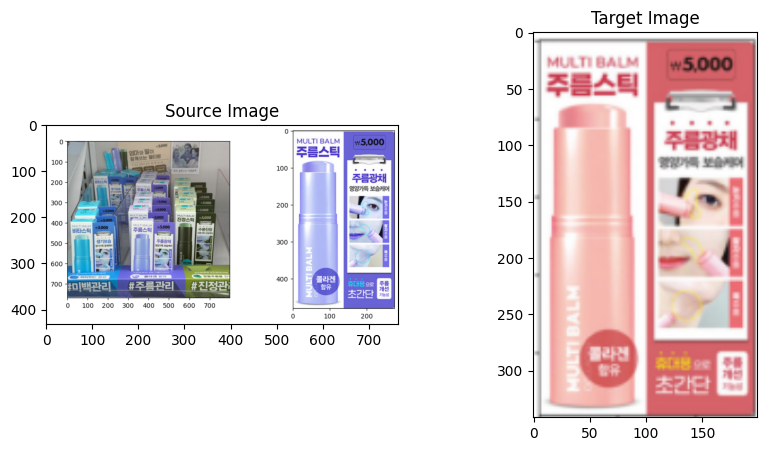

In [20]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/10기/컴퓨터비전_응용/data/beau_3.png'
target_path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/10기/컴퓨터비전_응용/data/new_target.png'

# Load images
image = cv2.imread(image_path)
target_image = cv2.imread(target_path)

# Check if images are loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}")
elif target_image is None:
    print(f"Error: Could not load target image from {target_path}")
else:
    # Convert BGR to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    target_image_rgb = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Source Image')
    axes[1].imshow(target_image_rgb)
    axes[1].set_title('Target Image')
    plt.show()

In [21]:
# template.shape
# (height, width, channel)

[[ 0.061626    0.0565078   0.05089397 ...  0.09285793  0.08121586
   0.06671396]
 [ 0.06544913  0.06023618  0.05449306 ...  0.10462786  0.09281056
   0.07813446]
 [ 0.06771111  0.06244585  0.05667875 ...  0.11615083  0.1042225
   0.08935999]
 ...
 [ 0.08255365  0.07666332  0.06809233 ... -0.01252885 -0.02255774
  -0.03586997]
 [ 0.08622248  0.08064667  0.07239251 ... -0.01588633 -0.02582858
  -0.03899072]
 [ 0.09027251  0.08481224  0.07664864 ... -0.02197817 -0.0317569
  -0.04470986]]


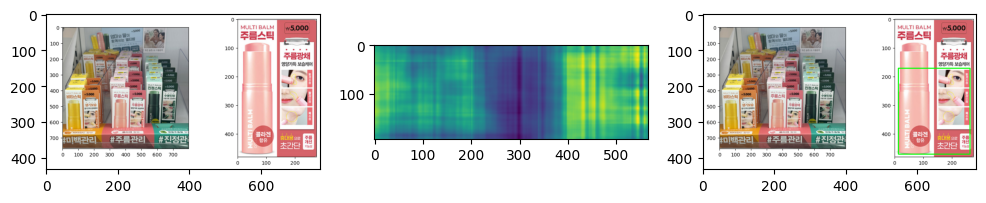

In [22]:
#1.그레이스케일로 변환
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

target = cv2.imread(target_path)
target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
target_gray = cv2.resize(target_gray, (200,240)) #타겟의 회전, 크기 변화, 밝기 변화 가 영향을 많이 미침
# 템플릿 크기 200*240px 조정 (**)
# 중요: 템플릿 매칭은 크기가 정확하게 맞아야 작동함

#2.템플릿의 너비와 높이를 찾음
w, h = target_gray.shape[::-1]
# 원래 shape는 (높이, 너비)순서임
# [::-1] 역순 >> (너비, 높이)
# 왜? 나중에 사각형 그릴 때 필요하다

#3.템플릿을 이미지에서 매칭해서 찾아봐!
#매칭 옵션 : SQDIFF(픽셀 제곱차이), CCORR(픽셀 곱의 합), CCOEFF(코사인유사도)  X NORMED(일정한 범위 내로 만듦)
result = cv2.matchTemplate(image_gray, target_gray, cv2.TM_CCOEFF_NORMED)
# SQDIFF(픽셀 제곱차이) 작을수록 유사
# CCORR(픽셀 곱의 합) 클수록 유사
# TM_CCOEFF_NORMED : 클수록 유사
# NORMED(일정한 범위 내로 만듦) 정규화 (0-1 범위로 만들기)
print(result) # 유사도 점수

#매칭 결과에서 최소값, 최대값, 최소값 위치, 최대값 위치를 찾으려고 함
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
# min_val: 가장 낮은 유사도 값
# min_loc : 가장 낮은 유사도 위치 (가장 안 비슷한 위치)

# max_val, max_loc : 가장 유사도 값이 높고, 가장 비슷한 위치(x,y) 좌표를 우리는 원해요

#시각화
top_left = max_loc #가능성이 높은 지역의 왼쪽 위 모서리(기준점으로 삼음)
#top_left = (x, y)형태라서 top_left[0]는 x좌표, top_left[1]는 y좌표
bottom_right = (top_left[0]+w, top_left[1]+h) #왼쪽 위 모서리를 기준으로 +너비, +높이해서 구한 오른쪽 아래 모서리
# (top_left[0]+w, top_left[1]+h) : x+w. y+h
matched = image.copy()
cv2.rectangle(matched, top_left, bottom_right, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image)
axes[1].imshow(result)
axes[2].imshow(matched)
plt.show()

유사도 점수 맵(score map)
- 형태: 히트맵
- 색상의 의미: 밝을 수록 유사하다(유사도 점수가 높다)/ 어두운 부분: 템플릿과 다르다


In [23]:
'''[[ 0.061626    0.0565078   0.05089397 ...  0.09285793  0.08121586
   0.06671396]
 [ 0.06544913  0.06023618  0.05449306 ...  0.10462786  0.09281056
   0.07813446]
 [ 0.06771111  0.06244585  0.05667875 ...  0.11615083  0.1042225
   0.08935999]
 ...
 [ 0.08255365  0.07666332  0.06809233 ... -0.01252885 -0.02255774
  -0.03586997]
 [ 0.08622248  0.08064667  0.07239251 ... -0.01588633 -0.02582858
  -0.03899072]
 [ 0.09027251  0.08481224  0.07664864 ... -0.02197817 -0.0317569
  -0.04470986]]'''

'[[ 0.061626    0.0565078   0.05089397 ...  0.09285793  0.08121586\n   0.06671396]\n [ 0.06544913  0.06023618  0.05449306 ...  0.10462786  0.09281056\n   0.07813446]\n [ 0.06771111  0.06244585  0.05667875 ...  0.11615083  0.1042225\n   0.08935999]\n ...\n [ 0.08255365  0.07666332  0.06809233 ... -0.01252885 -0.02255774\n  -0.03586997]\n [ 0.08622248  0.08064667  0.07239251 ... -0.01588633 -0.02582858\n  -0.03899072]\n [ 0.09027251  0.08481224  0.07664864 ... -0.02197817 -0.0317569\n  -0.04470986]]'

유사도 기준(-1<=rho<=1)

rho=1: 완벽하게 일치

rho>0.8: 유사도가 높음

0.5<rho<0.8: 적당히 비슷함

rho=0: 완전히 다름

In [24]:
target_gray.shape  # (높이, 너비)

(240, 200)

In [25]:
target_gray.shape[::-1] # (너비, 높이)

(200, 240)

In [26]:
target_gray.shape

(240, 200)

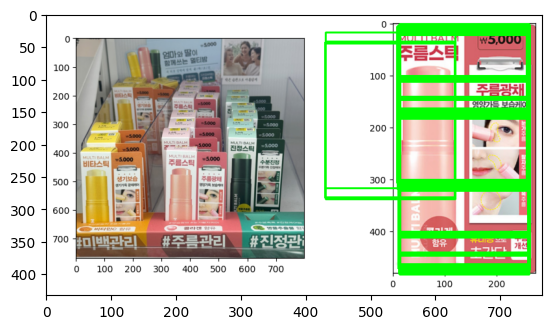

In [27]:
import cv2
import numpy as np
res=cv2.matchTemplate(image_gray, target_gray, cv2.TM_CCOEFF_NORMED)

threshold=0.3 #유사도 30% 이상인 위치 찾기(임계값 설정)
loc=np.where(res>=threshold) # 조건으로 결과 찾기

#loc(y좌표,x좌표(w,h))-> loc[::-1] 역순 (h,w)로 변환
for pt in zip(*loc[::-1]):
  bottom_right=(pt[0]+w, pt[1]+h)
  cv2.rectangle(image,pt,bottom_right,(0,255,0),2)

plt.imshow(image,cmap='gray')
plt.show()
